In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix


In [2]:
DATASET_PATH = "/content/drive/MyDrive/The IQ-OTHNCCD lung cancer dataset"   # change if needed

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25
NUM_CLASSES = 3


In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


In [4]:
train_gen = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_gen = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
print("Classes:", class_names)


Found 878 images belonging to 3 classes.
Found 219 images belonging to 3 classes.
Classes: ['Bengin cases', 'Malignant cases', 'Normal cases']


In [5]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # Freeze backbone

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
callbacks = [
    ModelCheckpoint(
        "best_lung_model.h5",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        verbose=1
    )
]


In [8]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.6593 - loss: 0.9286 
Epoch 1: val_accuracy improved from -inf to 0.82192, saving model to best_lung_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 621s 22s/step - accuracy: 0.6634 - loss: 0.9175 - val_accuracy: 0.8219 - val_loss: 0.5240 - learning_rate: 0.0010
Epoch 2/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - accuracy: 0.8584 - loss: 0.3380
Epoch 2: val_accuracy did not improve from 0.82192
28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 600ms/step - accuracy: 0.8581 - loss: 0.3386 - val_accuracy: 0.6986 - val_loss: 0.8332 - learning_rate: 0.0010
Epoch 3/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.8615 - loss: 0.3161
Epoch 3: val_accuracy improved from 0.82192 to 0.87215, saving model to best_lung_model.h5


28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 588ms/step - accuracy: 0.8617 - loss: 0.3157 - val_accuracy: 0.8721 - val_loss: 0.4977 - learning_rate: 0.0010
Epoch 4/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.8976 - loss: 0.2583
Epoch 4: val_accuracy did not improve from 0.87215
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 571ms/step - accuracy: 0.8971 - loss: 0.2591 - val_accuracy: 0.7260 - val_loss: 0.7538 - learning_rate: 0.0010
Epoch 5/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.8866 - loss: 0.2607
Epoch 5: val_accuracy did not improve from 0.87215
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 577ms/step - accuracy: 0.8869 - loss: 0.2603 - val_accuracy: 0.8539 - val_loss: 0.5326 - learning_rate: 0.0010
Epoch 6/25
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.8890 - loss: 0.2496
Epoch 6: val_accuracy did not improve from 0.87215

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 601ms/step - accuracy: 0.8890 - loss: 0.2492 - val_accu

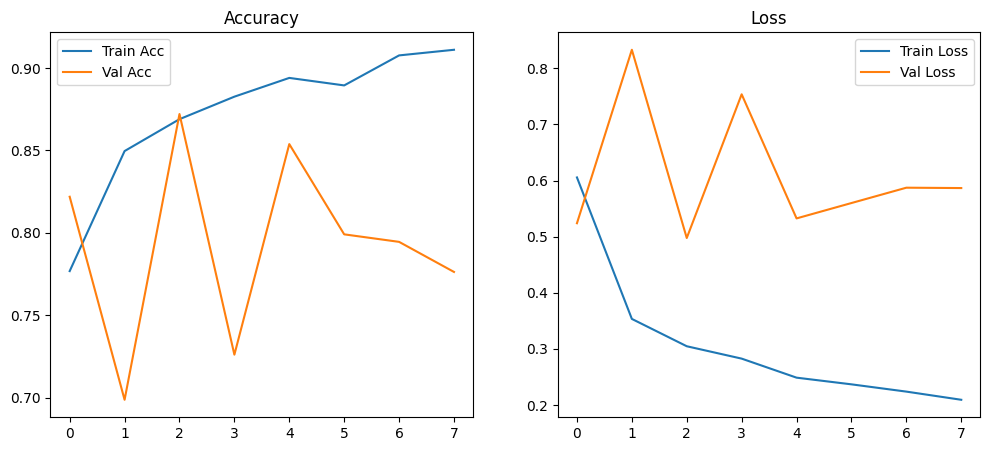

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()


In [10]:
val_gen.reset()
preds = model.predict(val_gen)
y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes


7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 991ms/step


In [11]:
print(classification_report(y_true, y_pred, target_names=class_names))


                 precision    recall  f1-score   support

   Bengin cases       0.54      0.29      0.38        24
Malignant cases       0.96      1.00      0.98       112
   Normal cases       0.81      0.87      0.84        83

       accuracy                           0.87       219
      macro avg       0.77      0.72      0.73       219
   weighted avg       0.86      0.87      0.86       219



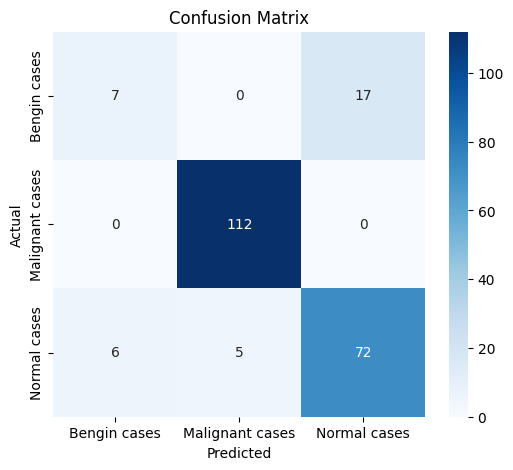

In [12]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [13]:
model.save("lung_cancer_full_model.h5")
print("Model saved successfully!")


Model saved successfully!


In [15]:
from tensorflow.keras.preprocessing import image

model = tf.keras.models.load_model("lung_cancer_full_model.h5")

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img = image.img_to_array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    preds = model.predict(img)
    class_id = np.argmax(preds)
    confidence = np.max(preds) * 100

    return class_names[class_id], confidence


In [16]:
img_path = "/content/drive/MyDrive/The IQ-OTHNCCD lung cancer dataset/Malignant cases/Malignant case (10).jpg"  # change path
label, conf = predict_image(img_path)

print("Prediction:", label)
print("Confidence:", round(conf, 2), "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Prediction: Malignant cases
Confidence: 99.93 %
